In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

In [2]:
# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [3]:
rna

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01310,ATMG01330,ATMG01340,ATMG01350,ATMG01360,ATMG01370,ATMG01375,ATMG01380,ATMG01390,ATMG01410
240614_mct_1_1_P2-4-E5-B7,0,0,0,836,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-L20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-K7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-D8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_1_P2-4-E5-L7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240614_mct_1_3_P1-3-K9-M5,0,0,0,2,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-B17,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-F17,0,0,0,151,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240614_mct_1_3_P1-3-K9-O17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Get raw counts
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Calculate fraction and handle NaNs
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

# Map cluster assignments and calculate cluster-wise mean
mCGN_frac['cluster'] = meta['merged_cluster']
cluster_meth_matrix = mCGN_frac.groupby('cluster').mean().T

# Filter for genes with at least 10% methylation in at least one cluster
filtered_meth_df = cluster_meth_matrix[cluster_meth_matrix.apply(lambda x: (x >= 0.1).any(), axis=1)]

print(f"Processed Methylation matrix shape: {filtered_meth_df.shape}")

Processed Methylation matrix shape: (10976, 17)


In [5]:
filtered_meth_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
gene,,,,,,,,,,,,,,,,,
AT1G01040,0.373896,0.453085,0.402800,0.340706,0.392736,0.373404,0.420332,0.431067,0.336317,0.302482,0.262409,0.401258,0.335501,0.412739,0.407538,0.413286,0.354696
AT1G01046,0.067529,0.129354,0.083053,0.057404,0.106707,0.058181,0.132723,0.134513,0.087273,0.029206,0.068243,0.053125,0.057390,0.079630,0.083333,0.080645,0.107456
AT1G01050,0.056427,0.076632,0.049561,0.045308,0.059733,0.038837,0.051946,0.072109,0.048802,0.054070,0.022076,0.058000,0.045580,0.070404,0.050690,0.122364,0.039995
AT1G01220,0.208149,0.254829,0.194764,0.163905,0.233234,0.171441,0.244789,0.268758,0.143602,0.140368,0.161566,0.222798,0.195925,0.266501,0.165224,0.212588,0.193672
AT1G01260,0.071932,0.114410,0.084004,0.075584,0.100605,0.073067,0.123416,0.121435,0.056663,0.062627,0.045401,0.069170,0.086661,0.098370,0.062322,0.094421,0.110106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01370,0.187546,0.269046,0.154203,0.174851,0.235590,0.133217,0.314669,0.335086,0.262064,0.124892,0.208668,0.155438,0.162954,0.308013,0.111264,0.103851,0.183677
ATMG01380,0.171589,0.273420,0.120809,0.161222,0.220199,0.116377,0.321406,0.311174,0.255713,0.156496,0.236930,0.134239,0.189731,0.256116,0.091177,0.106284,0.301023
ATMG01390,0.523476,0.621271,0.461034,0.405024,0.593090,0.369596,0.648210,0.658667,0.589276,0.343604,0.566321,0.441088,0.402850,0.655782,0.336510,0.429515,0.551172


In [4]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


In [15]:
rna_log1p

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01330,ATMG01340,ATMG01350,ATMG01360,ATMG01370,ATMG01375,ATMG01380,ATMG01390,ATMG01410,cluster
240614_mct_1_1_P2-4-E5-B7,0.0,0.000000,0.0,8.340533,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
240614_mct_1_1_P2-4-E5-L20,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
240614_mct_1_1_P2-4-E5-K7,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
240614_mct_1_1_P2-4-E5-D8,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14
240614_mct_1_1_P2-4-E5-L7,0.0,0.000000,0.0,2.080233,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240614_mct_1_3_P1-3-K9-M5,0.0,0.000000,0.0,3.891601,0.0,0.000000,0.0,0.0,0.000000,4.574489,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
240614_mct_1_3_P1-3-K9-B17,0.0,0.000000,0.0,0.000000,0.0,2.859359,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
240614_mct_1_3_P1-3-K9-F17,0.0,0.000000,0.0,5.283248,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
240614_mct_1_3_P1-3-K9-O17,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [11]:
cluster_rna_matrix

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
AT1G01010,0.060414,0.117021,0.048096,0.031763,0.041043,0.020625,0.041678,0.113005,0.040381,0.020117,0.136782,0.000000,0.178207,0.059046,0.016309,0.123274,0.103218
AT1G01020,0.867954,1.377313,0.576624,0.575061,0.719045,0.444421,1.047967,1.612992,0.677856,0.584201,0.755711,0.203666,0.682061,1.204037,0.221479,0.481391,0.903148
AT1G01030,0.214732,0.341753,0.143114,0.245864,0.215808,0.117127,0.122684,0.178724,0.127377,0.165419,0.251199,0.138163,0.323830,0.114429,0.057338,0.370302,0.032590
AT1G01040,1.044483,1.514967,1.098356,0.688672,0.844977,0.795467,1.123852,1.648007,0.783206,1.577694,1.278548,1.777067,0.619029,1.433840,0.631241,0.920084,1.413787
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
# Align genes across both modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    
    # Skip genes with zero variance
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    rho, p = spearmanr(rna_vals, meth_vals)
    valid_genes.append(gene)
    correlations.append(rho)
    p_values.append(p)

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes:")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes:
                rho   p_value       fdr
gene                                   
AT2G07638 -0.791667  0.000153  0.021649
AT2G10940 -0.772059  0.000282  0.024581
AT4G01130 -0.761673  0.000381  0.026661
AT1G17920 -0.730392  0.000870  0.036666
AT3G43270 -0.723039  0.001039  0.040192
AT4G30400 -0.723039  0.001039  0.040192
AT1G62030 -0.709994  0.001407  0.045536
AT2G07698 -0.681373  0.002597  0.057680
AT4G18970 -0.674020  0.003008  0.061253
AT2G13820 -0.669556  0.003282  0.063040
AT1G29910 -0.666667  0.003470  0.063958
AT2G07681 -0.657266  0.004144  0.069478
AT5G48690 -0.652656  0.004511  0.072397
AT2G28170 -0.649908  0.004742  0.073868
AT5G09840 -0.645211  0.005159  0.076072
AT2G01010 -0.644608  0.005214  0.076072
AT3G23450 -0.642157  0.005446  0.077252
AT2G05665 -0.623660  0.007468  0.089824
AT5G22860 -0.619252  0.008030  0.092172
AT2G07655 -0.614347  0.008693  0.095559


Found 323 significantly correlated genes.


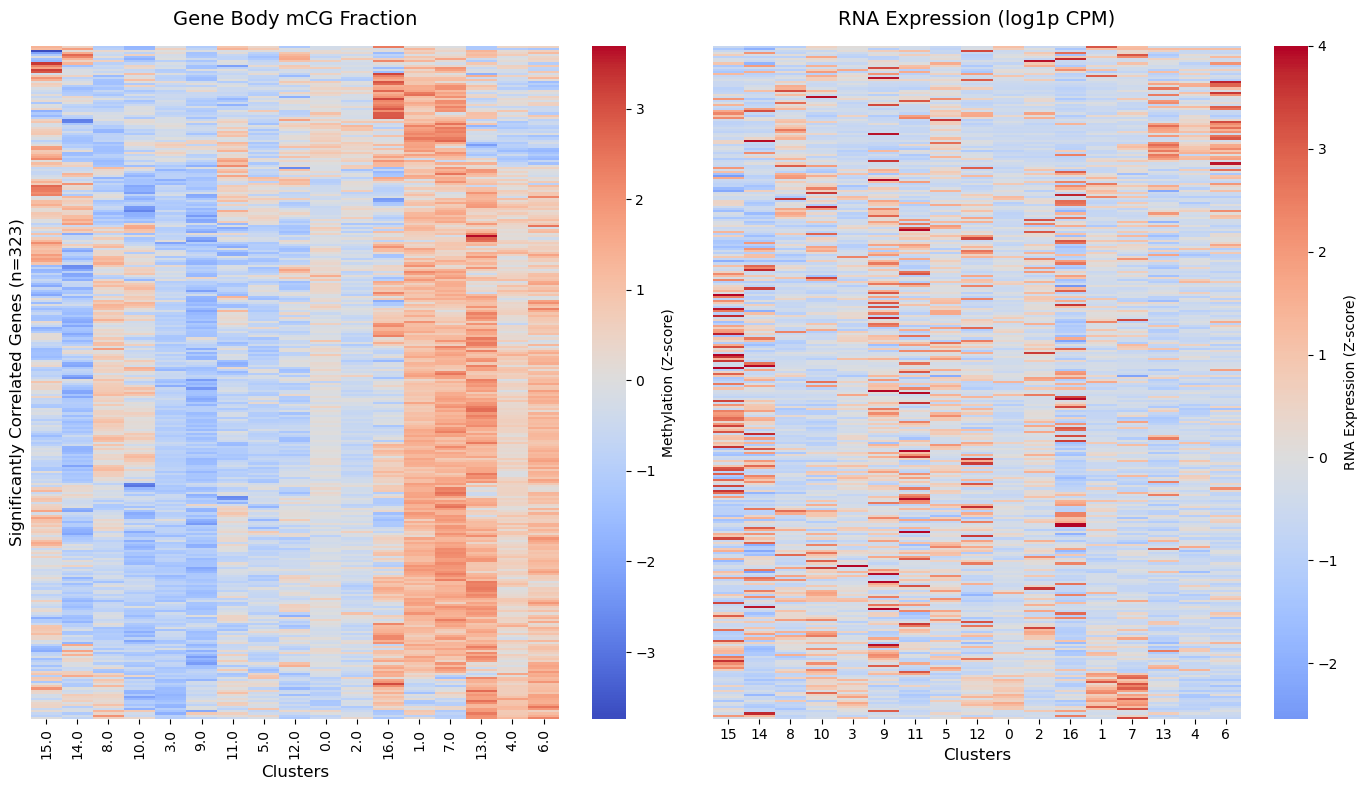

In [21]:
# Set significance thresholds
RHO_THRESH = -0.1
FDR_THRESH = 0.5

sig_genes = stats_df[(stats_df['rho'] <= RHO_THRESH) & (stats_df['fdr'] <= FDR_THRESH)].index
print(f"Found {len(sig_genes)} significantly correlated genes.")

# Subset and prepare visualization matrices
vis_rna = final_rna_df.loc[sig_genes]
vis_meth = final_meth_df.loc[sig_genes].copy()

# Apply the specific baseline rule for zero methylation windows to improve visual contrast
vis_meth[vis_meth == 0] = -0.2

# Z-score normalization for heatmap comparability
vis_rna_z = vis_rna.apply(zscore, axis=1)
vis_meth_z = vis_meth.apply(zscore, axis=1)

# Generate clustering order based on methylation
cluster_grid = sns.clustermap(vis_meth_z, cmap="coolwarm", figsize=(2, 2))
plt.close() # Close temporary figure
row_order = cluster_grid.dendrogram_row.reordered_ind
col_order = cluster_grid.dendrogram_col.reordered_ind

# Sort matrices
vis_meth_sorted = vis_meth_z.iloc[row_order, col_order]
vis_rna_sorted = vis_rna_z.iloc[row_order, col_order]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [1, 1]})

sns.heatmap(vis_meth_sorted, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation (Z-score)'}, yticklabels=False)
ax1.set_title("Gene Body mCG Fraction", fontsize=14, pad=15)
ax1.set_xlabel("Clusters", fontsize=12)
ax1.set_ylabel(f"Significantly Correlated Genes (n={len(sig_genes)})", fontsize=12)

sns.heatmap(vis_rna_sorted, cmap="coolwarm", center=0, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=14, pad=15)
ax2.set_xlabel("Clusters", fontsize=12)
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("rna_meth_negative_correlation.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()